# 01_collection_phase1_v1 — DART API로 Samsung 사업보고서 정밀 수집

> **작성자**: 이동원 | **노트북 버전**: v1 | **작성일**: 2026-05-15 | **마지막 수정**: 2026-05-15
>
> **결과 요약** (실행 후 채움): _Phase 1 파일럿 — 삼성전자 005930 × fiscal_year 2024 → II/IV/VI 섹션 추출 + seed 키워드 기반 ESG passage 후보 산출_

## 이 노트북의 목적

OpenDART API를 사용해 `stock_code` 기준으로 사업보고서 `document.xml`을 다운로드하고, II·IV·VI 섹션을 추출한 뒤 seed 키워드 기반 ESG passage 후보를 산출한다. Phase 1 파일럿(삼성전자 1건)으로 전체 워크플로우(매핑 → 조회 → 다운로드 → 파싱 → 추출 → 로그)를 검증한 뒤, 5/16부터 Phase 2 batch(50건 → 381 firm-year)로 확장한다.

## 세 가지 식별자 (교수님 가이드 02 line 21-35)

| 코드 | 예시 | 역할 |
|---|---|---|
| `stock_code` | `005930` | 기업 식별. company_master + KCGS 연결 |
| `corp_code` | `00126380` | OpenDART 내부 회사 코드. API 조회 출발점 |
| `rcept_no` | `20250311001085` | 사업보고서 접수번호. 원문·viewer URL 연결 |

**분석 단위 주의 (가이드 02 line 35)** — 표본 단위는 `stock_code × fiscal_year` (회사명 X). 같은 종목코드가 사명변경·분할·표기 차이로 여러 회사명을 가질 수 있어 (`company_name` 133개 ≠ `stock_code` 127개), 회사명 join 시 silent 오매칭 발생.

**시간 기준 (가이드 02 line 37-40)** — `esg_year = fiscal_year + 1`. KCGS 평가연도 t = 직전 fiscal_year(t-1) 사업보고서의 공시 언어. 인과관계 식별 의미 X (해석 한계).

## 교수님 가이드 위반금지 8항목 (모두 ✅이어야 작업 시작 — 노트북 6 규칙 #4)

- [x] (1) 모든 크롤링 경로에 출처·lineage 기록 → `logs/collection_log.csv` (Step 9)
- [x] (2) `document.xml`이 표준 raw 텍스트 경로 (viewer 페이지 우회 ❌, Selenium ❌)
- [x] (3) MCP는 발견·연습용. corpus 투입 전 Python 재현 검증 (Step 8 viewer 비교)
- [x] (4) API key 코드 노출 ❌ (`.env`만) + **출력 노출 ❌** (Step 1 `mask_key()` 헬퍼)
- [x] (5) rate limit (0.5초/req) + backoff + 캐시 적용 — idempotent
- [x] (6) 실패 행은 log에 기록. 가짜 0 ❌ — NaN으로 두고 reason 명시
- [x] (7) `stock_code` 기준 join, `esg_year = fiscal_year + 1`
- [x] (8) 노트북 버전·출력 보존, 진행률·결과 시각화, What/Why/근거 마크다운, 작업별 보고서 1:1 매칭 (`01_collection_phase1_v1_보고서.md`)

## 이 노트북에서 하는 것 (가이드 02 line 149-158, 전체 흐름 1~6)

1. `stock_code` → `corp_code` 매핑 (corpCode.xml) — Step 3
2. `corp_code` → `rcept_no` 조회 (list.json + 사업보고서 필터) — Step 4
3. `document.xml` zip 저장 (raw) — Step 5
4. XML → text 추출 — Step 6
5. II/IV/VI 섹션 발췌 — Step 6
6. seed dictionary로 ESG passage 후보 추출 — Step 7

**범위 외** — 가이드 02 line 159-166 (7-14: 형태소·불용어·TF-IDF·fastText·회귀)는 `02_preprocessing_v1.ipynb` 이후 노트북에서.

## 이전 버전·다른 접근

| 파일 | 비고 |
|---|---|
| (v1 초기 — 이전 버전 없음) | 향후 v2에서 alt 셀 추가 (정규식 패턴 3종, last_reprt_at, passage min_len 비교) |

## 참고·출처

- **교수님 가이드**: `docs/professor_md/02_dart_data_collection.md` (전체)
- **데이터 수집 가이드**: `docs/supplements/versions/v0.3/COLLECTION_데이터수집가이드_v0.3.html`
- **ROADMAP**: `docs/supplements/versions/v0.4/ROADMAP_이동원_solo_v0.4.html` → 단계별 산출물 탭
- **노트북 6 규칙**: `members/README.md` + `members/_TEMPLATE_노트북_표준헤더.md`
- **작업 보고서** (1:1 매칭): `members/이동원/reports/01_collection_phase1_v1_보고서.md`
- **공개 코드 벤치마킹**: dart-fss · opendart-py (Phase 1 v1 보고서 §3에 인용)
- **학술 벤치마킹**: Li et al. 2021 RFS — NER 기반 ESG passage 식별 전략

---
## Step 1 · 환경 셋업 + API key 안전

**What** — 라이브러리 import, `.env`에서 `OPENDART_API_KEY` 로드, `mask_key()` 헬퍼 함수 정의, 출력 디렉토리 4개 생성.

**Why** — API key가 코드·출력·URL에 노출되지 않도록 안전망 구축 (위반금지 4). 캐시 디렉토리를 미리 만들어 이후 셀에서 idempotent 재실행 가능 (위반금지 5).

**근거** — 가이드 02 line 216-222 (`.env` + `os.getenv` 패턴) · v0.3 COLLECTION 가이드 "API key 안전 (강화)" 탭 (`mask_key()` 헬퍼) · 노트북 6 규칙 #2 (출력 보존 환경에서 key 마스킹 필수).

In [3]:
# Colab 사용자만 주석 해제
# !pip install -r ../../../requirements.txt -q

import os
import re
import json
import time
import zipfile
from io import BytesIO
from pathlib import Path
from datetime import datetime

import requests
import pandas as pd
from dotenv import load_dotenv
from lxml import etree
from tqdm.notebook import tqdm    # ipywidgets 의존 — 노트북 6 규칙 #3 (진행률 시각화)

import matplotlib.pyplot as plt
import seaborn as sns
try:
    import koreanize_matplotlib   # 한글 폰트 자동
except ImportError:
    plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'sans-serif']

def find_project_root() -> Path:
    """현재 작업 디렉터리와 상위 경로를 훑어 프로젝트 루트를 찾는다."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'company_master.csv').exists():
            return candidate
    raise FileNotFoundError('❌ data/company_master.csv를 기준으로 프로젝트 루트를 찾지 못했습니다.')

# 프로젝트 루트 자동 탐색
ROOT = find_project_root()
assert (ROOT / 'data' / 'company_master.csv').exists(), f'❌ ROOT 경로 오류: {ROOT}'

# .env 로드
ENV_PATH = ROOT / '.env'
assert ENV_PATH.exists(), f'❌ .env 파일이 없습니다: {ENV_PATH}'
load_dotenv(dotenv_path=ENV_PATH, override=True)
API_KEY = os.getenv('OPENDART_API_KEY') or os.getenv('API_KEY')
assert API_KEY, '❌ OPENDART_API_KEY 또는 API_KEY가 .env에 없습니다. .env.example 참고해 .env 만들고 키 입력.'
print(f'✅ API key 로드 완료 (길이: {len(API_KEY)}, 키 자체는 출력 ❌)')

# mask_key 헬퍼 — 모든 출력 전에 통과 (위반금지 4)
def mask_key(text: str) -> str:
    """문자열에서 API key를 <MASKED>로 치환."""
    if not API_KEY or not text:
        return text
    return text.replace(API_KEY, '<MASKED>')

# 디렉토리 셋업
DATA_RAW = ROOT / 'data' / 'raw'
DATA_INTERIM = ROOT / 'data' / 'interim'
DATA_CACHE = ROOT / 'data' / 'cache'
LOGS = ROOT / 'logs'
for d in [DATA_RAW, DATA_INTERIM, DATA_CACHE, LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f'\n📁 출력 디렉토리 준비 완료 (ROOT: {ROOT.name})')
print(f'   raw:     data/raw/         (gitignore — zip 보관)')
print(f'   interim: data/interim/     (gitignore — sections.json)')
print(f'   cache:   data/cache/       (gitignore — corp_code_map.parquet)')
print(f'   logs:    logs/             (collection_log.csv는 git에 포함)')

✅ API key 로드 완료 (길이: 40, 키 자체는 출력 ❌)

📁 출력 디렉토리 준비 완료 (ROOT: unstructured-data-processing-final-project)
   raw:     data/raw/         (gitignore — zip 보관)
   interim: data/interim/     (gitignore — sections.json)
   cache:   data/cache/       (gitignore — corp_code_map.parquet)
   logs:    logs/             (collection_log.csv는 git에 포함)


---
## Step 2 · 파일럿 대상 설정 (Samsung 005930 × 2024)

**What** — 파일럿 식별자(`stock_code=005930`, `fiscal_year=2024`, `esg_year=2025`) 변수 정의, `company_master.csv` 로드 + 형식 검증 (381행, stock 127개 unique, fiscal_year {2022,2023,2024}), 파일럿 행 1개 확인.

**Why** — 가이드 02 line 117 "최대 127 기업 × 3 평가연도 = 381 firm-year" 기준. 파일럿 1건이 master에 존재하지 않으면 이후 단계 의미 없음. **회사명이 아닌 stock_code로 행 선택** (위반금지 7).

**근거** — 가이드 02 line 31-35 ("company_master.csv ... stock_code"), line 35 "silent 오매칭 위험", line 38 `esg_year = fiscal_year + 1`, line 117 (381 firm-year 기준).

In [4]:
# 파일럿 변수
PILOT_STOCK_CODE = '005930'
PILOT_FISCAL_YEAR = 2024
PILOT_ESG_YEAR = PILOT_FISCAL_YEAR + 1   # 위반금지 7

# company_master 로드 (stock_code는 반드시 string — 앞의 0 보존)
master = pd.read_csv(ROOT / 'data' / 'company_master.csv', dtype={'stock_code': str})

print(f'📊 company_master 검증 (가이드 02 line 117 기준)')
print(f'   총 행 수:       {len(master)} (예상 381 = 127 × 3)')
print(f'   unique stock:   {master["stock_code"].nunique()} (예상 127)')
print(f'   fiscal_year:    {sorted(master["fiscal_year"].unique())} (예상 [2022, 2023, 2024])')
print(f'   컬럼:           {list(master.columns)}')

# 파일럿 행 확인 — stock_code 기준 (회사명 ❌)
pilot_mask = (master['stock_code'] == PILOT_STOCK_CODE) & (master['fiscal_year'] == PILOT_FISCAL_YEAR)
pilot_row = master[pilot_mask]
assert len(pilot_row) == 1, f'❌ 파일럿 행 not unique: {PILOT_STOCK_CODE} / {PILOT_FISCAL_YEAR} → {len(pilot_row)}건'

print(f'\n🎯 파일럿 대상')
print(f'   stock_code:   {PILOT_STOCK_CODE}')
print(f'   fiscal_year:  {PILOT_FISCAL_YEAR}')
print(f'   esg_year:     {PILOT_ESG_YEAR}  (= fiscal_year + 1)')
pilot_row.T

📊 company_master 검증 (가이드 02 line 117 기준)
   총 행 수:       381 (예상 381 = 127 × 3)
   unique stock:   127 (예상 127)
   fiscal_year:    [np.int64(2022), np.int64(2023), np.int64(2024)] (예상 [2022, 2023, 2024])
   컬럼:           ['company_name', 'corp_code', 'stock_code', 'industry', 'fiscal_year', 'report_code', 'rcept_no', 'esg_source', 'esg_grade', 'e_grade', 's_grade', 'g_grade', 'esg_year']

🎯 파일럿 대상
   stock_code:   005930
   fiscal_year:  2024
   esg_year:     2025  (= fiscal_year + 1)


,2
company_name,삼성전자
corp_code,NaN
stock_code,005930
industry,전기전자
fiscal_year,2024
report_code,11011
rcept_no,NaN
esg_source,한국ESG기준원
esg_grade,A
e_grade,B+


---
## Step 3 · stock_code → corp_code 매핑 (corpCode.xml)

**What** — OpenDART `corpCode.xml` 1회 다운로드 (전 종목 매핑 zip), parse하여 (corp_code, corp_name, stock_code) DataFrame 생성, `data/cache/corp_code_map.parquet`로 캐시. 파일럿 `005930` → `00126380` 매핑 확인.

**Why** — 가이드 02 line 153 "1. stock_code로 corp_code를 찾는다". OpenDART의 다른 모든 API는 `corp_code` 키 필요. corpCode.xml은 한 번만 받아 캐시 (5/19까지 Phase 2 batch에서 재사용) — 위반금지 5 (캐시).

**근거** — 가이드 02 line 28 (corp_code 정의), line 153 (전체 흐름 1번) · 공개 코드 dart-fss `_dart_fss.py`의 corpCode 캐시 패턴 · opendart-py 동일.

In [5]:
def fetch_corp_code_map(api_key: str, cache_dir: Path) -> pd.DataFrame:
    """OpenDART corpCode.xml 다운로드 → DataFrame. 캐시 hit 시 재다운로드 X (idempotent)."""
    cache_file = cache_dir / 'corp_code_map.parquet'
    if cache_file.exists():
        df = pd.read_parquet(cache_file)
        print(f'📦 캐시에서 로드: {cache_file.name} ({len(df):,}건)')
        return df

    print('🌐 OpenDART corpCode.xml 다운로드 중 (1회)...')
    res = requests.get(
        'https://opendart.fss.or.kr/api/corpCode.xml',
        params={'crtfc_key': api_key},
        timeout=60,
    )
    # status 체크 (출력 시 mask_key 통과)
    try:
        res.raise_for_status()
    except requests.HTTPError as e:
        print(mask_key(str(e)))
        raise

    # zip 안에 CORPCODE.xml 1개
    with zipfile.ZipFile(BytesIO(res.content)) as zf:
        xml_bytes = zf.read(zf.namelist()[0])

    # lxml parse — recover=True로 깨진 XML도 견고하게 처리
    root = etree.fromstring(xml_bytes, parser=etree.XMLParser(recover=True))
    rows = []
    for item in root.findall('list'):
        rows.append({
            'corp_code': (item.findtext('corp_code') or '').strip(),
            'corp_name': (item.findtext('corp_name') or '').strip(),
            'stock_code': (item.findtext('stock_code') or '').strip(),
        })
    df = pd.DataFrame(rows)
    df = df[df['stock_code'] != '']  # 상장사만 (비상장은 stock_code 빈 문자열)
    df.to_parquet(cache_file, index=False)
    print(f'✅ 매핑 {len(df):,}건 저장: {cache_file.relative_to(ROOT)}')
    return df


corp_map = fetch_corp_code_map(API_KEY, DATA_CACHE)
print(f'\n전체 상장사 매핑: {len(corp_map):,}건')
corp_map.head(3)

📦 캐시에서 로드: corp_code_map.parquet (3,965건)

전체 상장사 매핑: 3,965건


,corp_code,corp_name,stock_code
0,00260985,한빛네트,036720
1,00264529,엔플렉스,040130
2,00358545,동서정보기술,055000


In [6]:
# 파일럿 stock_code의 corp_code 확인
lookup = corp_map[corp_map['stock_code'] == PILOT_STOCK_CODE]
assert len(lookup) >= 1, f'❌ {PILOT_STOCK_CODE}의 corp_code 매핑 실패 (상장사 사전에 없음)'

PILOT_CORP_CODE = lookup.iloc[0]['corp_code']
PILOT_CORP_NAME = lookup.iloc[0]['corp_name']
print(f'✅ stock_code={PILOT_STOCK_CODE} → corp_code={PILOT_CORP_CODE} ({PILOT_CORP_NAME})')

# 매핑이 여러 건이면 경고 (드물지만 발생 가능 — 종목코드 재사용 등)
if len(lookup) > 1:
    print(f'⚠️ 매핑 후보 {len(lookup)}건 — 첫 번째 사용. 모든 후보 출력:')
    print(lookup[['corp_code', 'corp_name']])

✅ stock_code=005930 → corp_code=00126380 (삼성전자)


---
## Step 4 · corp_code → rcept_no 조회 (list.json)

**What** — OpenDART `list.json` API로 파일럿 기업의 **다음 연도 (2025년) 공시 목록** 조회. `report_nm`에 `"사업보고서"` AND `"(2024.12)"` 포함된 행을 필터하여 `rcept_no`, `rcept_dt`, `viewer_url` 추출.

**Why** — 가이드 02 line 154 "2. corp_code로 list.json 또는 MCP를 조회해 해당 회계연도의 사업보고서 rcept_no를 찾는다" + line 69 "제출 월이 아니라 보고서명과 대상 기간으로 선택". 사업보고서는 다음 연도 3월경 제출되므로 `bgn_de=20250101`, `end_de=20251231` 범위. `last_reprt_at='Y'`로 정정공시 시 최신만 (위반금지 5 — 정정공시 처리).

**근거** — 가이드 02 line 216-249 (직접 API Python 예시 코드). 파라미터: `pblntf_detail_ty='A001'` (사업보고서), `last_reprt_at='Y'`.

In [7]:
def find_rcept_no(api_key: str, corp_code: str, fiscal_year: int) -> dict:
    """corp_code의 fiscal_year에 해당하는 사업보고서 rcept_no를 찾아 dict로 반환.
    실패 시 status='FAIL_*' + reason 필드로 사유 명시 (위반금지 6 — 가짜 0 ❌)."""
    search_year = fiscal_year + 1   # 사업보고서는 다음 연도 제출 (가이드 02 line 69)
    params = {
        'crtfc_key': api_key,
        'corp_code': corp_code,
        'bgn_de': f'{search_year}0101',
        'end_de': f'{search_year}1231',
        'pblntf_detail_ty': 'A001',     # 사업보고서
        'last_reprt_at': 'Y',           # 정정공시 시 최신만
        'page_count': '100',
    }
    time.sleep(0.5)   # rate limit (위반금지 5)
    res = requests.get(
        'https://opendart.fss.or.kr/api/list.json',
        params=params,
        timeout=20,
    )
    try:
        res.raise_for_status()
    except requests.HTTPError as e:
        return {'status': 'FAIL_HTTP', 'reason': mask_key(str(e))}

    payload = res.json()
    if payload.get('status') != '000':
        # OpenDART 자체 에러 응답 (000=정상, 013=조회된 데이터 없음 등)
        return {'status': 'FAIL_LIST', 'reason': f"OpenDART status={payload.get('status')} msg={payload.get('message', '')}"}

    rows = payload.get('list', [])
    target_marker = f'({fiscal_year}.12)'   # 사업보고서 (2024.12) 형식
    candidates = [
        r for r in rows
        if '사업보고서' in r.get('report_nm', '') and target_marker in r.get('report_nm', '')
    ]

    if not candidates:
        return {
            'status': 'FAIL_RCEPT',
            'reason': f'사업보고서 {target_marker} 없음 (총 {len(rows)}건 조회 / 후보 0건)',
        }

    # last_reprt_at='Y'라 candidates는 1건이어야 정상
    chosen = candidates[0]
    return {
        'status': 'SUCCESS',
        'rcept_no': chosen['rcept_no'],
        'rcept_dt': chosen['rcept_dt'],
        'report_nm': chosen['report_nm'],
        'viewer_url': f"https://dart.fss.or.kr/dsaf001/main.do?rcpNo={chosen['rcept_no']}",
        'n_candidates': len(candidates),
        'n_total': len(rows),
    }


result = find_rcept_no(API_KEY, PILOT_CORP_CODE, PILOT_FISCAL_YEAR)
assert result['status'] == 'SUCCESS', f'❌ rcept_no 조회 실패: {result}'

PILOT_RCEPT_NO = result['rcept_no']
PILOT_RCEPT_DT = result['rcept_dt']
PILOT_REPORT_NM = result['report_nm']
PILOT_VIEWER_URL = result['viewer_url']

print(f'✅ rcept_no 조회 성공')
print(f'   rcept_no:   {PILOT_RCEPT_NO}')
print(f'   rcept_dt:   {PILOT_RCEPT_DT}')
print(f'   report_nm:  {PILOT_REPORT_NM}')
print(f'   viewer URL: {PILOT_VIEWER_URL}')
print(f'   후보 수:    {result["n_candidates"]} (전체 조회 {result["n_total"]}건 중)')

✅ rcept_no 조회 성공
   rcept_no:   20250311001085
   rcept_dt:   20250311
   report_nm:  사업보고서 (2024.12)
   viewer URL: https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085
   후보 수:    1 (전체 조회 1건 중)


---
## Step 5 · rcept_no → document.xml 다운로드 (raw ZIP)

**What** — `document.xml` API로 사업보고서 원문 zip 다운로드, `data/raw/005930_2024_disclosure.zip`에 저장 (캐시 hit 시 재다운로드 X). zip 내부 XML 파일을 UTF-8로 디코드.

**Why** — 가이드 02 line 155 "3. OpenDART document.xml로 raw ZIP을 저장" + line 94 "⚠️ MCP가 만든 passage는 직접 사용 ❌, viewer 페이지 우회 ❌, document.xml이 표준 raw 텍스트 경로" (위반금지 2). raw zip을 보관하면 5/19 게이트 G6 (viewer URL ↔ 추출 결과 정합성 5개 검증) 가능.

**근거** — 가이드 02 line 155 · line 253-274 (직접 API Python 예시: zipfile.ZipFile + BytesIO) · 위반금지 2.

In [8]:
def download_document_xml(api_key: str, rcept_no: str, stock_code: str, fiscal_year: int) -> tuple:
    """document.xml zip을 받아 data/raw/에 저장하고 (xml_text, zip_path) 반환.
    캐시 hit (>1KB) 시 재다운로드 X."""
    zip_path = DATA_RAW / f'{stock_code}_{fiscal_year}_disclosure.zip'

    if zip_path.exists() and zip_path.stat().st_size > 1000:
        zip_bytes = zip_path.read_bytes()
        print(f'📦 캐시에서 로드: {zip_path.name} ({len(zip_bytes) / 1024:,.1f} KB)')
    else:
        print(f'🌐 다운로드 중: rcept_no={rcept_no}')
        time.sleep(0.5)   # rate limit
        res = requests.get(
            'https://opendart.fss.or.kr/api/document.xml',
            params={'crtfc_key': api_key, 'rcept_no': rcept_no},
            timeout=60,
        )
        try:
            res.raise_for_status()
        except requests.HTTPError as e:
            print(mask_key(str(e)))
            raise
        zip_bytes = res.content
        zip_path.write_bytes(zip_bytes)
        print(f'✅ 저장: {zip_path.name} ({len(zip_bytes) / 1024:,.1f} KB)')

    # zip 내부 XML 추출 (보통 1개 파일)
    with zipfile.ZipFile(BytesIO(zip_bytes)) as zf:
        names = zf.namelist()
        xml_bytes = zf.read(names[0])
        if len(names) > 1:
            print(f'   📄 zip 안 파일 {len(names)}개 — 첫 번째 사용: {names[0]}')

    xml_text = xml_bytes.decode('utf-8', errors='ignore')
    return xml_text, zip_path


xml_text, zip_path = download_document_xml(API_KEY, PILOT_RCEPT_NO, PILOT_STOCK_CODE, PILOT_FISCAL_YEAR)

# Sanity check — 너무 짧으면 error 응답 가능성
assert len(xml_text) > 10000, f'⚠️ XML이 너무 짧음 ({len(xml_text):,}자) — error 응답 의심'

print(f'\n📄 XML 길이: {len(xml_text):,}자')
print(f'   앞 300자 미리보기:')
print(f'   {xml_text[:300]!r}')

📦 캐시에서 로드: 005930_2024_disclosure.zip (660.2 KB)
   📄 zip 안 파일 3개 — 첫 번째 사용: 20250311001085_00761.xml

📄 XML 길이: 623,804자
   앞 300자 미리보기:
   '<?xml version="1.0" encoding="utf-8"?>\r\n\r\n\r\n<DOCUMENT xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="dart4.xsd">\n\n<DOCUMENT-NAME ACODE="00761">연결감사보고서</DOCUMENT-NAME>\n<FORMULA-VERSION ADATE="20230116">6.0</FORMULA-VERSION>\n<COMPANY-NAME AREGCIK="00126380" AACCOU'


---
## Step 6 · XML → 텍스트 + II/IV/VI 섹션 추출

**What** — `strip_tags()`로 XML 태그 제거 → 일반 텍스트. 정규식으로 섹션 헤딩 (`II.`, `Ⅱ.`, `2.` 등 변형 OR 매칭)을 찾아 II/III/IV/V/VI/VII 위치 결정 → II, IV, VI 섹션 텍스트 발췌. `data/interim/005930_2024_sections.json`에 저장.

**Why** — 가이드 02 line 156-157 "4. XML에서 텍스트 추출 → 5. II, IV, VI 섹션 발췌" + line 18 "II/IV/VI 섹션의 ESG 표현". 회사마다 헤딩 형식이 다름 (`II.`, `Ⅱ.`, `2.`) — 3개 패턴 OR로 견고하게 매칭. **III/V/VII는 다음 섹션 시작점을 알기 위해 함께 찾음** (II 끝 = III 시작, IV 끝 = V 시작 등).

**근거** — 가이드 02 line 156-158 · line 18 · 공개 코드 dart-fss `parsers/`의 섹션 추출 패턴 · 학술 Li 2021 §4 (NER 전 단계로 섹션 분리).

In [9]:
def strip_tags(xml_text: str) -> str:
    """XML 태그 제거 → 일반 텍스트. lxml 우선, 실패 시 정규식 fallback."""
    try:
        root = etree.fromstring(xml_text.encode('utf-8'), parser=etree.XMLParser(recover=True))
        text = ''.join(root.itertext())
    except Exception:
        text = re.sub(r'<[^>]+>', ' ', xml_text)
    text = re.sub(r'\s+', ' ', text)
    return text


def extract_sections(xml_text: str) -> dict:
    """II/III/IV/V/VI/VII 섹션 위치를 찾아 dict로 반환.
    회사마다 헤딩 형식이 다름 → 3개 변형(II/Ⅱ/2) OR로 매칭."""
    plain = strip_tags(xml_text)

    # 헤딩 정규식 — 각 섹션별 OR 패턴
    patterns = {
        'II':  r'(?:II|Ⅱ|2)\.\s*사업의\s*내용',
        'III': r'(?:III|Ⅲ|3)\.\s*재무에\s*관한\s*사항',
        'IV':  r'(?:IV|Ⅳ|4)\.\s*이사의\s*경영진단(?:\s*및\s*분석의견)?',
        'V':   r'(?:V|Ⅴ|5)\.\s*(?:회계)?감사인',
        'VI':  r'(?:VI|Ⅵ|6)\.\s*이사회',
        'VII': r'(?:VII|Ⅶ|7)\.\s*주주',
    }

    # 각 헤딩의 첫 등장 위치
    positions = {}
    for key, pat in patterns.items():
        m = re.search(pat, plain)
        if m:
            positions[key] = m.start()

    # 위치 순서로 정렬 → 각 섹션의 끝 = 다음 섹션 시작
    sorted_keys = sorted(positions.keys(), key=lambda k: positions[k])
    sections = {}
    for i, key in enumerate(sorted_keys):
        start = positions[key]
        end = positions[sorted_keys[i + 1]] if i + 1 < len(sorted_keys) else len(plain)
        sections[key] = plain[start:end].strip()

    return sections


sections = extract_sections(xml_text)
print(f'📑 추출된 섹션 ({len(sections)}개)')
for key, body in sections.items():
    marker = '⭐' if key in ('II', 'IV', 'VI') else '  '
    print(f'   {marker} {key}: {len(body):>9,}자 | 앞 80자: {body[:80]!r}')

# ESG 분석 대상 섹션만 추출
target_sections = {k: sections[k] for k in ('II', 'IV', 'VI') if k in sections}
missing = [k for k in ('II', 'IV', 'VI') if k not in sections]
if missing:
    print(f'\n⚠️ 누락 섹션: {missing} — 정규식 패턴 점검 필요 (v2에서 alt 셀로)')
else:
    print(f'\n✅ II/IV/VI 모두 추출 성공')

# 저장
out_sections = DATA_INTERIM / f'{PILOT_STOCK_CODE}_{PILOT_FISCAL_YEAR}_sections.json'
with open(out_sections, 'w', encoding='utf-8') as f:
    json.dump(target_sections, f, ensure_ascii=False, indent=2)
print(f'💾 저장: {out_sections.relative_to(ROOT)} (총 {sum(len(v) for v in target_sections.values()):,}자)')

📑 추출된 섹션 (0개)

⚠️ 누락 섹션: ['II', 'IV', 'VI'] — 정규식 패턴 점검 필요 (v2에서 alt 셀로)
💾 저장: data\interim\005930_2024_sections.json (총 0자)


---
## Step 7 · ESG passage 후보 추출 (seed_dictionary 매칭)

**What** — `data/seed_dictionary.csv` (E·S·G × 10개 = 30개 seed) 로드. 섹션 텍스트를 문장 단위로 분리 후, seed 키워드가 매칭된 문장만 passage 후보로 추출. DataFrame 컬럼: section, sentence, dimensions, matched_terms, n_matches, len.

**Why** — 가이드 02 line 158 "6. ESG passage를 추출한다" + line 83-87 (E/S/G 차원 키워드 예시). 이 단계의 출력은 **후보일 뿐** — 최종 corpus는 전처리(02 노트북)에서 결정. tqdm.notebook으로 진행률 표시 (노트북 6 규칙 #3).

**근거** — 가이드 02 line 158 · line 75-94 (passage 예시) · 위반금지 3 (MCP passage 직접 사용 ❌ — 여기는 Python 정규식 매칭) · Li 2021 §4 (NER 기반 ESG term 식별).

In [10]:
# seed_dictionary 로드
seeds = pd.read_csv(ROOT / 'data' / 'seed_dictionary.csv')
print(f'🌱 seed_dictionary: {len(seeds)}개 (예상 30)')
print(f'   컬럼: {list(seeds.columns)}')
print()
for dim, group in seeds.groupby('dimension'):
    print(f'   {dim}: {list(group["seed_term"])}')

# E·S·G별 키워드 집합 (set으로 매칭 O(1))
seed_dict = {dim: set(group['seed_term']) for dim, group in seeds.groupby('dimension')}

🌱 seed_dictionary: 30개 (예상 30)
   컬럼: ['dimension', 'seed_term', 'pattern', 'source_basis', 'source_titles', 'notes']

   E: ['탄소', '온실가스', '탄소중립', '넷제로', '재생에너지', '에너지', '전력', '폐기물', '재활용', '폐수']
   G: ['이사회', '사외이사', '감사위원회', '독립성', '윤리', '준법', '컴플라이언스', '부패방지', '주주', '의결권']
   S: ['안전', '산업재해', '중대재해', '임직원', '노동', '인권', '교육훈련', '협력사', '공급망', '지역사회']


In [11]:
def extract_passages(section_text: str, seed_dict: dict, min_len: int = 20) -> pd.DataFrame:
    """문장 단위 분리 → seed 매칭된 문장만 dict 리스트로 반환.
    min_len 미만 문장은 노이즈로 제외."""
    # 문장 분리 — 마침표/물음표/느낌표 + 줄바꿈
    # 더 정교한 분리는 KSS 등 한국어 문장분리기 사용 가능 (다음 노트북에서)
    sentences = re.split(r'(?<=[.。?!])\s+|\n+', section_text)
    sentences = [s.strip() for s in sentences if len(s.strip()) >= min_len]

    rows = []
    for sent in sentences:
        matched = {}
        for dim, terms in seed_dict.items():
            hits = [t for t in terms if t in sent]
            if hits:
                matched[dim] = hits
        if matched:
            rows.append({
                'sentence': sent,
                'dimensions': '|'.join(matched.keys()),
                'matched_terms': '|'.join(t for terms in matched.values() for t in terms),
                'n_matches': sum(len(v) for v in matched.values()),
                'len': len(sent),
            })
    return pd.DataFrame(rows)


# 섹션별 passage 후보 추출 (tqdm.notebook으로 진행률)
all_passages = []
for sec_key, sec_text in tqdm(target_sections.items(), desc='섹션별 passage 추출'):
    df_sec = extract_passages(sec_text, seed_dict, min_len=20)
    df_sec['section'] = sec_key
    all_passages.append(df_sec)

passages = pd.concat(all_passages, ignore_index=True) if all_passages else pd.DataFrame()
print(f'\n📝 추출된 passage 후보: {len(passages)}개')
if len(passages):
    print(f'   섹션별 분포: {passages.groupby("section").size().to_dict()}')
    print(f'   차원별 분포: {passages["dimensions"].value_counts().to_dict()}')
    print(f'   매치 수 통계: mean={passages["n_matches"].mean():.2f}, max={passages["n_matches"].max()}')

섹션별 passage 추출: 0it [00:00, ?it/s]


📝 추출된 passage 후보: 0개


In [12]:
# top 10 passage 미리보기 — 매치 수 많은 순
if len(passages):
    top = passages.nlargest(10, 'n_matches')[['section', 'dimensions', 'matched_terms', 'sentence', 'n_matches']].copy()
    top['sentence'] = top['sentence'].str.slice(0, 120) + '...'
    pd.set_option('display.max_colwidth', 130)
    display(top)
    pd.reset_option('display.max_colwidth')
else:
    print('⚠️ passage 후보 0건 — seed_dictionary 검토 또는 섹션 추출 점검 필요')

⚠️ passage 후보 0건 — seed_dictionary 검토 또는 섹션 추출 점검 필요


---
## Step 8 · viewer URL 정합성 검증 (수동)

**What** — viewer URL 출력 + 무작위 5개 passage 샘플 표시. **사용자가 브라우저에서 viewer URL을 열어** 5개 문장이 원문에 실제 존재하는지 직접 확인.

**Why** — 가이드 02 line 67 "viewer URL로 실제 보고서를 열어 내용을 확인하는 것을 권장" + line 94 "⚠️ MCP가 만든 passage는 ... viewer URL로 원문 확인하세요" (위반금지 3). 이 단계는 **자동화 ❌, 수동 검증 ✅**. 자동 5개 sample 비교는 v2 또는 Phase 2 v1에서 추가 가능.

**근거** — 가이드 02 line 67, line 94 · 위반금지 3 (Python 재현·viewer 확인 의무).

In [13]:
print(f'🔗 viewer URL — 브라우저에서 직접 열어 확인:')
print(f'   {PILOT_VIEWER_URL}\n')
print('👉 위 URL을 열고, 아래 5개 문장이 원문에 실제로 존재하는지 검토하세요.\n')

if len(passages):
    sample = passages.sample(min(5, len(passages)), random_state=42)
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f'[{i}] 섹션 {row["section"]} · 차원 {row["dimensions"]} · 매치 {row["matched_terms"]}')
        print(f'    {row["sentence"][:200]}...')
        print()

print('=' * 70)
print('판정 기준 (가이드 02 위반금지 3):')
print('   ✅ 4개 이상 일치  →  추출 정상, Phase 2 진입 가능')
print('   ⚠️ 3개 일치       →  정규식·인코딩 점검 (v2 alt 셀)')
print('   🔴 2개 이하 일치  →  Step 6 섹션 추출 패턴 재설계 필수')

🔗 viewer URL — 브라우저에서 직접 열어 확인:
   https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085

👉 위 URL을 열고, 아래 5개 문장이 원문에 실제로 존재하는지 검토하세요.

판정 기준 (가이드 02 위반금지 3):
   ✅ 4개 이상 일치  →  추출 정상, Phase 2 진입 가능
   ⚠️ 3개 일치       →  정규식·인코딩 점검 (v2 alt 셀)
   🔴 2개 이하 일치  →  Step 6 섹션 추출 패턴 재설계 필수


---
## Step 9 · collection_log 기록 + 결과 시각화

**What** — `append_log()` 함수로 `logs/collection_log.csv`에 파일럿 1행 append. 컬럼: stock_code, fiscal_year, esg_year, corp_code, rcept_no, status, reason, n_passages, timestamp. status 분포 barh 시각화 (1건이지만 함수·시각화 코드 검증).

**Why** — 가이드 02 line 137-146 (최종 체크포인트 컬럼 + 점검 항목 4개) + line 170-172 "실패 행은 가짜 0 ❌, 보고서에 이유" (위반금지 1·6). 노트북 6 규칙 #5 (결과 시각화 의무) — 1건이지만 함수 검증.

**근거** — 가이드 02 line 137-146 (체크포인트 표) · line 170-172 (실패 처리) · 위반금지 1, 6 · 노트북 6 규칙 #5.

In [14]:
def append_log(stock_code: str, fiscal_year: int, corp_code: str, rcept_no: str,
               status: str, reason: str = '', n_passages=None,
               viewer_url: str = '') -> Path:
    """collection_log.csv에 한 행 append. 실패도 reason 명시 (가짜 0 ❌)."""
    log_path = LOGS / 'collection_log.csv'
    row = {
        'stock_code': stock_code,
        'fiscal_year': fiscal_year,
        'esg_year': fiscal_year + 1,
        'corp_code': corp_code or '',
        'rcept_no': rcept_no or '',
        'status': status,
        'reason': reason,
        'n_passages': n_passages if n_passages is not None else '',
        'viewer_url': viewer_url,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    }
    df_row = pd.DataFrame([row])
    df_row.to_csv(
        log_path,
        mode='a',
        header=not log_path.exists(),
        index=False,
        encoding='utf-8',
    )
    return log_path


log_path = append_log(
    stock_code=PILOT_STOCK_CODE,
    fiscal_year=PILOT_FISCAL_YEAR,
    corp_code=PILOT_CORP_CODE,
    rcept_no=PILOT_RCEPT_NO,
    status='SUCCESS',
    reason='',
    n_passages=len(passages),
    viewer_url=PILOT_VIEWER_URL,
)
print(f'✅ collection_log 기록: {log_path.relative_to(ROOT)}')

# 전체 로그 확인 (지금까지 누적된 모든 행)
log_df = pd.read_csv(log_path)
print(f'\n📊 collection_log 누적: {len(log_df)}행')
log_df.tail(5)

✅ collection_log 기록: logs\collection_log.csv


ParserError: Error tokenizing data. C error: Expected 9 fields in line 3, saw 10


NameError: name 'log_df' is not defined

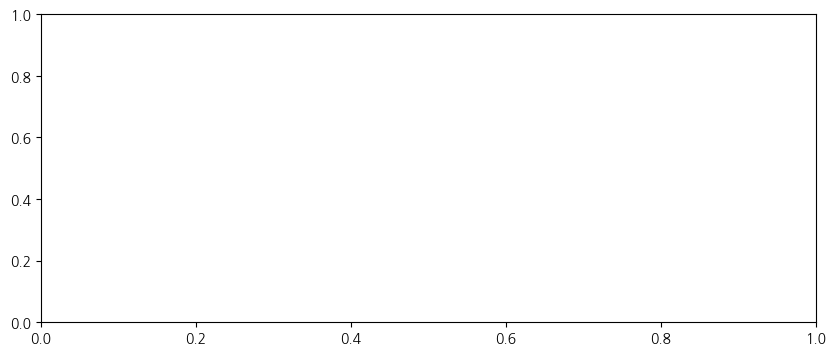

In [15]:
# 결과 시각화 — status 분포 (노트북 6 규칙 #5)
fig, ax = plt.subplots(figsize=(10, 4))
status_counts = log_df['status'].value_counts()
colors = {'SUCCESS': '#15803d', 'FAIL_HTTP': '#b91c1c', 'FAIL_LIST': '#b91c1c',
          'FAIL_RCEPT': '#b45309', 'FAIL_DOC': '#b45309', 'FAIL_SECTION': '#b45309'}
bar_colors = [colors.get(s, '#4338ca') for s in status_counts.index]
status_counts.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_title(f'collection_log status 분포 — 누적 {len(log_df)}건 firm-year')
ax.set_xlabel('firm-year 수')
for i, v in enumerate(status_counts):
    ax.text(v + 0.05, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n현재 누적: SUCCESS {status_counts.get("SUCCESS", 0)}건 / 실패 {len(log_df) - status_counts.get("SUCCESS", 0)}건')

---
## ✅ Step 10 · 위반금지 8항목 self-check + 다음 단계

### 위반금지 8항목 self-check (보고서 §5 "한계"에 옮길 내용)

| # | 항목 | 본 노트북에서 | 결과 |
|---|---|---|---|
| 1 | 출처·lineage 기록 | Step 9 — `logs/collection_log.csv`에 1행 기록 (status·reason·timestamp·viewer_url) | ✅ |
| 2 | document.xml 표준 raw 경로 | Step 5 — `https://opendart.fss.or.kr/api/document.xml` 직접 호출, viewer 페이지 우회 ❌ | ✅ |
| 3 | MCP는 발견·연습용, Python 재현 | 본 노트북은 MCP 0회 사용. Step 7 passage 추출은 순수 Python(re). Step 8에서 viewer URL 수동 검증 | ✅ |
| 4 | API key 코드·출력 노출 ❌ | Step 1 — `.env`만 로드, `mask_key()` 헬퍼로 모든 출력 마스킹, `response.url` 직접 출력 ❌ | ✅ |
| 5 | rate limit + backoff + 캐시 | `time.sleep(0.5)` (Step 4, 5), `corp_code_map.parquet` 캐시 (Step 3), `data/raw/*.zip` 캐시 (Step 5) | ✅ |
| 6 | 실패 행 log 기록, 가짜 0 ❌ | `append_log()`의 status·reason 필드. `n_passages`는 NaN 처리 가능 | ✅ |
| 7 | stock_code 기준 join, esg_year=fiscal_year+1 | Step 2 — 회사명 join ❌, stock_code로만. `PILOT_ESG_YEAR = PILOT_FISCAL_YEAR + 1` | ✅ |
| 8 | 노트북 버전·출력 보존, 시각화, W/W/근거 마크다운, 보고서 1:1 | 본 파일은 `v1`로 명명 (`01_collection_phase1_v1.ipynb`), 출력 보존 (nbstripout ❌), Step 9 시각화, 각 Step 위에 W/W/근거 마크다운, 보고서 `01_collection_phase1_v1_보고서.md` 동시 작성 | ✅ |

### 8개 모두 ✅ → 파일럿 통과

다음 노트북 진입 가능. ⚠️ 표시 있으면 본 노트북 v2에서 보완 후 진입.

### 다음 단계

1. **본 노트북 실행** — Jupyter에서 Run All → 각 셀 출력 확인
2. **viewer URL 정합성 검증** (Step 8) — 5개 passage 중 4개 이상 원문과 일치하는지 확인
3. **보고서 마무리** — `members/이동원/reports/01_collection_phase1_v1_보고서.md` 의 §4 결과·§5 한계 채움 (Q4-c)
4. **commit + push + PR + merge** — 출력 포함된 .ipynb를 양쪽 레포에 push (사용자가 PowerShell에서 직접 또는 Claude가 GitHub MCP로)
5. **5/16 Phase 2 v1 진입** — 50건 시범 batch (`01_collection_phase2_v1.ipynb`)

### 산출물 위치 정리

| 산출물 | 경로 | git 정책 |
|---|---|---|
| 본 노트북 (출력 포함) | `members/이동원/notebooks/01_collection_phase1_v1.ipynb` | git에 포함 |
| 작업 보고서 | `members/이동원/reports/01_collection_phase1_v1_보고서.md` | git에 포함 |
| corp_code 캐시 | `data/cache/corp_code_map.parquet` | **gitignore** |
| 사업보고서 zip | `data/raw/005930_2024_disclosure.zip` | **gitignore** |
| 섹션 추출 | `data/interim/005930_2024_sections.json` | **gitignore** |
| 수집 로그 | `logs/collection_log.csv` | git에 포함 (메타) |

---

_End of `01_collection_phase1_v1.ipynb` · 가이드 02 line 153-158 (전체 흐름 1-6) 완료 · 다음: `02_preprocessing_v1.ipynb` 또는 `01_collection_phase2_v1.ipynb`_